In [ ]:
# Import library

import umap 
import numpy as np
import pandas as pd
import re
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from scipy.sparse.csgraph import connected_components
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Kind of messy code because there was a point where I was trying to get my dbscan clustering to exactly match Aisling's and figure out the differences
# between our two clusterings, I will clean it up later

# Ran on qc3 (you have to change the path before running)
# Includes psuedotime plot and umap of dogs

In [10]:
# Read in da data

qc3_df = pd.read_csv('qc3_duplicates_removed_prevalence_1pct.csv', 
                     index_col=0)

# Sanity check
print("QC3 dataset shape:", qc3_df.shape)

print("QC3 dataset head:")
display(qc3_df.head())

QC3 dataset shape: (1125, 377)
QC3 dataset head:


,age,weight,k__Bacteria,k__Bacteria|p__Actinobacteria,k__Bacteria|p__Actinobacteria|c__Actinomycetia,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii|t__SGB33755,...,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma|s__Mesomycoplasma_molare,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma|s__Mesomycoplasma_molare|t__SGB28759,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_canis,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_canis|t__SGB5941,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_edwardii,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_edwardii|t__SGB28786,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_maculosa,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_maculosa|t__SGB28743
sample_id,,,,,,,,,,,,,,,,,,,,,
DW31240510808865,5.0,170.0,1,0.028636,0.028636,0.015828,0.015828,0.008205,0.002611,0.002611,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DW31240510802107,1.0,166.0,1,0.004132,0.004132,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DW31240510806513,6.0,166.0,1,0.015808,0.015808,0.007428,0.007428,0.000913,0.000000,0.000000,...,0.0,0.0,0.0,0.002536,0.002536,0.002536,0.0,0.0,0.0,0.0
DW31240510806340,4.0,165.0,1,0.019847,0.019847,0.003984,0.003984,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000691,0.000691,0.000691,0.0,0.0,0.0,0.0
DW31240663106415,3.0,165.0,1,0.009659,0.009659,0.009034,0.009034,0.005672,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [11]:
# Seperate da data: metadata and features

metadata = qc3_df[['age', 'weight']]

features = qc3_df.drop(columns=['age', 'weight'])

# Sanity checkies
print("Metadata shape:", metadata.shape)
print("Features shape:", features.shape)

# Metadata head
print("Metadata head:")
display(metadata.head())

# Features head
print("Features head:")
display(features.head())


Metadata shape: (1125, 2)
Features shape: (1125, 375)
Metadata head:


,age,weight
sample_id,,
DW31240510808865,5.0,170.0
DW31240510802107,1.0,166.0
DW31240510806513,6.0,166.0
DW31240510806340,4.0,165.0
DW31240663106415,3.0,165.0


Features head:


,k__Bacteria,k__Bacteria|p__Actinobacteria,k__Bacteria|p__Actinobacteria|c__Actinomycetia,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii|t__SGB33755,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii|t__SGB86824,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_respiraculi,...,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma|s__Mesomycoplasma_molare,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mesomycoplasma|s__Mesomycoplasma_molare|t__SGB28759,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_canis,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_canis|t__SGB5941,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_edwardii,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_edwardii|t__SGB28786,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_maculosa,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales|f__Mycoplasmataceae|g__Mycoplasmopsis|s__Mycoplasmopsis_maculosa|t__SGB28743
sample_id,,,,,,,,,,,,,,,,,,,,,
DW31240510808865,1,0.028636,0.028636,0.015828,0.015828,0.008205,0.002611,0.002611,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DW31240510802107,1,0.004132,0.004132,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
DW31240510806513,1,0.015808,0.015808,0.007428,0.007428,0.000913,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.002536,0.002536,0.002536,0.0,0.0,0.0,0.0
DW31240510806340,1,0.019847,0.019847,0.003984,0.003984,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000691,0.000691,0.000691,0.0,0.0,0.0,0.0
DW31240663106415,1,0.009659,0.009659,0.009034,0.009034,0.005672,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


In [12]:
# Verify relative abundances
features.sum(axis=1).describe()

count    1125.000000
mean        7.718168
std         0.404953
min         4.185371
25%         7.703587
50%         7.845683
75%         7.913107
max         8.000001
dtype: float64

In [13]:
# Display the first 20 feature column names: Wanna check out order level cols
for c in features.columns[:20]:
    print(c)

k__Bacteria
k__Bacteria|p__Actinobacteria
k__Bacteria|p__Actinobacteria|c__Actinomycetia
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii|t__SGB33755
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_bowdenii|t__SGB86824
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_respiraculi
k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales|f__Actinomycetaceae|g__Actinomyces|s__Actinomyces_respiraculi|t__

In [14]:
# Only choose order level features (those that start with 'o__' and don't include ogbs)
order_features = [ 
    column for column in features.columns
    if "|o__" in column and "|f__" not in column
    and "|o__OFGB" not in column
]

# -> Create a new dataframe with only order level features
order_features_df = features[order_features]

# After, check if everything sums to 1 - now that OGBS are gone -> check after renormalizing everything sums to 1
print("Sum of order level features per row:")
print(order_features_df.sum(axis=1).describe())

renorm_order_features_df = order_features_df.div(
    order_features_df.sum(axis=1), 
    axis=0)

# -> check after renormalizing everything sums to 1
print("Sum of renormalized order level features per row:")
print(renorm_order_features_df.sum(axis=1).describe())

# Sanity checkies
print("Order level features shape:", order_features_df.shape)

# Order level features head
print("Renormalized Order level features head:")
display(renorm_order_features_df.head())

# Log10 transform the renormalized data
pseudocount = 1e-5
log10_renorm_order_features = np.log10(renorm_order_features_df + pseudocount)

# Sanity check dat
print("Describe: Log 10 Transformed Order Features:",log10_renorm_order_features.describe())
print("Whole dataset minimum:", log10_renorm_order_features.min().min())
print("Whole dataset maximum:", log10_renorm_order_features.max().max())

Sum of order level features per row:
count    1125.000000
mean        0.997027
std         0.020593
min         0.556473
25%         0.999835
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64
Sum of renormalized order level features per row:
count    1.125000e+03
mean     1.000000e+00
std      1.425107e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64
Order level features shape: (1125, 27)
Renormalized Order level features head:


,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Micrococcales,k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Propionibacteriales,k__Bacteria|p__Bacteroidota|c__Bacteroidia|o__Bacteroidales,k__Bacteria|p__Bacteroidota|c__Flavobacteriia|o__Flavobacteriales,k__Bacteria|p__Elusimicrobia|c__Endomicrobia|o__Endomicrobiales,k__Bacteria|p__Firmicutes|c__Bacilli|o__Bacillales,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactobacillales,k__Bacteria|p__Firmicutes|c__Clostridia|o__Eubacteriales,...,k__Bacteria|p__Proteobacteria|c__Deltaproteobacteria|o__Desulfovibrionales,k__Bacteria|p__Proteobacteria|c__Epsilonproteobacteria|o__Campylobacterales,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Enterobacterales,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Moraxellales,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Pasteurellales,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Pseudomonadales,k__Bacteria|p__Proteobacteria|c__Gammaproteobacteria|o__Xanthomonadales,k__Bacteria|p__Spirochaetes|c__Spirochaetia|o__Spirochaetales,k__Bacteria|p__Synergistetes|c__Synergistia|o__Synergistales,k__Bacteria|p__Tenericutes|c__Mollicutes|o__Mycoplasmatales
sample_id,,,,,,,,,,,,,,,,,,,,,
DW31240510808865,0.015828,0.002862,0.004453,0.005493,0.326549,0.299921,0.0,0.000000,0.000000,0.002101,...,0.013203,0.024818,0.0,0.011095,0.009869,0.0,0.062381,0.011921,0.0,0.000000
DW31240510802107,0.000000,0.000000,0.004132,0.000000,0.082946,0.036419,0.0,0.130164,0.004993,0.000000,...,0.000000,0.000000,0.0,0.057094,0.019959,0.0,0.000000,0.000000,0.0,0.000000
DW31240510806513,0.007427,0.000328,0.004491,0.003562,0.068141,0.226999,0.0,0.005355,0.000000,0.000000,...,0.000000,0.013555,0.0,0.022739,0.046755,0.0,0.203262,0.000000,0.0,0.002536
DW31240510806340,0.003984,0.000000,0.015551,0.000312,0.009283,0.629644,0.0,0.001557,0.000606,0.000000,...,0.000000,0.005838,0.0,0.065193,0.020435,0.0,0.036437,0.000000,0.0,0.000691
DW31240663106415,0.009041,0.000000,0.000491,0.000135,0.671229,0.092018,0.0,0.000894,0.000000,0.000554,...,0.002381,0.008498,0.0,0.075588,0.040158,0.0,0.003009,0.024946,0.0,0.000000


Describe: Log 10 Transformed Order Features:        k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Actinomycetales  \
count                                        1125.000000                   
mean                                           -2.717480                   
std                                             1.230262                   
min                                            -5.000000                   
25%                                            -3.068645                   
50%                                            -2.260499                   
75%                                            -1.868834                   
max                                            -0.086954                   

       k__Bacteria|p__Actinobacteria|c__Actinomycetia|o__Corynebacteriales  \
count                                        1125.000000                     
mean                                           -3.970692                     
std                                 

In [15]:
# UMAP creation

# UMAP reducer for correlation distance -> more common in gene expression studies, pattern of abundances matter more than abundances themselves
reducer_corr_dist = umap.UMAP(
    metric='correlation',
    n_neighbors=12,
    min_dist=0.25,
    random_state=42
)
embed_corr_dist = reducer_corr_dist.fit_transform(log10_renorm_order_features)

# Check the shape of the UMAP embedding
print("UMAP embedding shape:", embed_corr_dist.shape)
# Check if the index of metadata and log_order_abundance are equal
print(metadata.index.equals(log10_renorm_order_features.index))

/Users/madeline/Desktop/lab2/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (1125, 2)
True


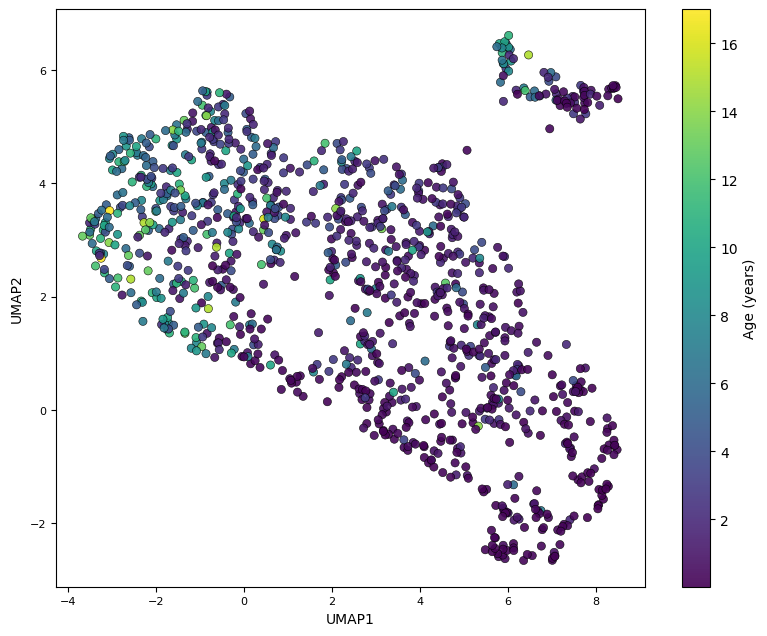

In [16]:
# Plot UMAP: Corr_Dist
fig, ax = plt.subplots(figsize=(9.5,7.5))

plot = ax.scatter(
    embed_corr_dist[:,0],
    embed_corr_dist[:,1],
    c=metadata["age"],
    cmap="viridis",
    s=35,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.4
)

# missing_samp_plt = plt.scatter(
    # missing_sam_df["UMAP 1 coordinate"],
    # missing_sam_df["UMAP 2 coordinate"],
    # c="red",
    # s=100,
    # alpha=0.9,
    # edgecolor="black",
    # linewidth=0.7
# )

ax.set_xlabel("UMAP1", fontsize=10)
ax.set_ylabel("UMAP2", fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)

# ax.set_title(
    # "Sample (Dog) UMAP\n(log10(Order Level Relative Abundances)) - Correlation Distance",
    # fontsize=12
# )

cbar = fig.colorbar(plot)
cbar.set_label("Age (years)", fontsize=10)

fig.savefig("dog_sample_umap.pdf", bbox_inches="tight")
plt.show()

In [17]:
# Create a table with sample IDs and their corresponding UMAP coordinates

umap_data = pd.DataFrame({
    "sample_id": log10_renorm_order_features.index,
    "UMAP 1 coordinate": embed_corr_dist[:, 0],
    "UMAP 2 coordinate": embed_corr_dist[:, 1]
})

# Add age for pseudotime analysis
umap_data["age"] = metadata["age"].values

# Check check
display(umap_data.head())
print("Samples without ages:", umap_data["age"].isna().sum())  # Check for missing values in the age column

print(umap_data[["UMAP 1 coordinate", "UMAP 2 coordinate"]].describe())

,sample_id,UMAP 1 coordinate,UMAP 2 coordinate,age
0,DW31240510808865,-2.619969,4.804618,5.0
1,DW31240510802107,4.935235,-0.760614,1.0
2,DW31240510806513,3.559147,3.896090,6.0
3,DW31240510806340,3.974505,3.866204,4.0
4,DW31240663106415,-1.189800,3.427663,3.0


Samples without ages: 0
       UMAP 1 coordinate  UMAP 2 coordinate
count        1125.000000        1125.000000
mean            2.620949           2.298406
std             3.342228           2.140111
min            -3.677278          -2.657029
25%            -0.439709           0.693948
50%             2.960792           2.620201
75%             5.519543           3.874831
max             8.509974           6.609872


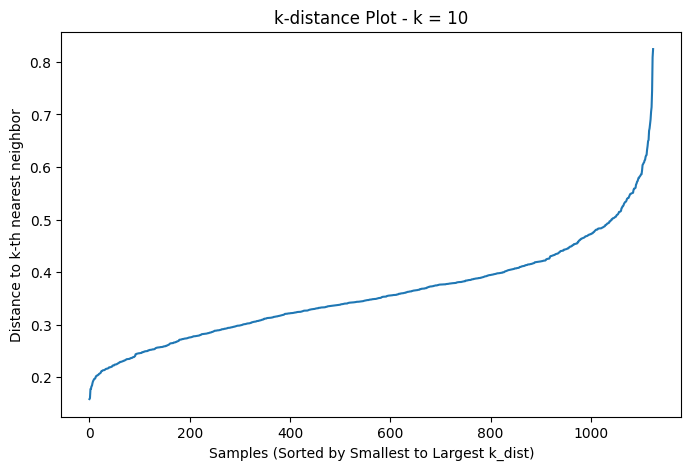

In [18]:
# Create k distance plot to determine eps

# define the model
near_neighbors_model = NearestNeighbors(n_neighbors=10)

# Fit the model to the data
near_neighbors_model.fit(embed_corr_dist)

dist_to_neighbors, neighbor_indicies = near_neighbors_model.kneighbors(embed_corr_dist)

# Extract distances from the 10th nearest neighbor
k_dist = dist_to_neighbors[:, 9]

# Sort k_dist from small to large
k_dist = np.sort(k_dist)

# K_dist plot
k_dist_plt = plt.figure(figsize=(8,5))

plt.plot(k_dist)

plt.xlabel("Samples (Sorted by Smallest to Largest k_dist)")
plt.ylabel("Distance to k-th nearest neighbor")
plt.title("k-distance Plot - k = 10")

plt.show()

In [19]:
# Run DBSCAN clustering on the UMAP embedding
DB_scan = DBSCAN(
    eps=0.55,
    min_samples=10
)

cluster_categories = DB_scan.fit_predict(embed_corr_dist)

# Save the cluster labels in the umap_data
umap_data["dbscan_cluster"] = cluster_categories

# Check the first 20 cluster categories assigned by DBSCAN
print(cluster_categories[:20])

# Check the number of samples in each cluster category
pd.Series(cluster_categories).value_counts().sort_index()


[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0]


-1       3
 0    1043
 1      79
Name: count, dtype: int64

In [20]:
# See the ids in cluster 1: my db scan
cluster_1_ids = umap_data[
    umap_data["dbscan_cluster"].isin([1,-1])
]

# CHECK! 
display(cluster_1_ids.head())
print(f"# of samples", {len(cluster_1_ids)})

# After read in Aisling's file -> code to compare sample ids




,sample_id,UMAP 1 coordinate,UMAP 2 coordinate,age,dbscan_cluster
10,DW31240510808940,6.366138,5.683161,7.0,1
11,DW31240510804170,6.936400,5.801916,4.0,1
12,DW31240510808962,7.095850,5.879021,4.0,1
13,DW31240663105385,7.479946,5.534629,1.5,1
14,DW31240663106366,7.724261,5.630301,2.5,1


# of samples {82}


Now I have to check the coordinates to isolate the upper right hand cluster


In [21]:
# Upper cluster isolate sample IDs based on visual guess
upper_rt_cluster = umap_data[
    (umap_data["UMAP 1 coordinate"] > 5.5) &
    (umap_data["UMAP 2 coordinate"] > 5.2)
]

print(f"Number of samples in the upper right cluster: {len(upper_rt_cluster)}")
display(upper_rt_cluster.head())

Number of samples in the upper right cluster: 77


,sample_id,UMAP 1 coordinate,UMAP 2 coordinate,age,dbscan_cluster
10,DW31240510808940,6.366138,5.683161,7.0,1
11,DW31240510804170,6.936400,5.801916,4.0,1
12,DW31240510808962,7.095850,5.879021,4.0,1
13,DW31240663105385,7.479946,5.534629,1.5,1
14,DW31240663106366,7.724261,5.630301,2.5,1


Go an inspect sample IDs from Aisling's cluster 1 and the new version

In [22]:
# Test sample filtering algorithm on one string/sample name

samp = "WGS-PL17__DW31240510801997_S237_L005_R1"

# Find the sample name that matches the pattern DW + didgits
match_obj = re.search(r'DW\d+', samp)

# Convert the match object to a string if a match is found
print(match_obj.group())

# Test the DWO pattern -- DW or DWO, use the ? to make the O optional

print(re.search(r"DWO?\d+", "DW31240510801974").group())
print(re.search(r"DWO?\d+", "DWO31240510801974").group())

DW31240510801997
DW31240510801974
DWO31240510801974


In [23]:
# Compare visual assesment of cluster 1 with Aisling's cluster 1 via DBSCAN
upper_right_cluster_sample_ids = upper_rt_cluster["sample_id"].tolist()
sample_umap_cluster1_db_scan = pd.read_csv('DB_scan_cluster1.csv')

# Function to extract the DW + digits pattern from sample IDs for comparison

def get_dw_samp_id(sample_id):

    match_object = re.search(r'DWO?\d+', sample_id)
    return match_object.group()

# Apply the function to the sample_id column in the v1 cluster dataframe
sample_umap_cluster1_db_scan["sample_id"] = sample_umap_cluster1_db_scan["sample_id"].apply(get_dw_samp_id)
# Check my work
print('Stripped Sample IDs from DBSCAN', sample_umap_cluster1_db_scan["sample_id"].head(10))

# One sample didn't fit the pattern -> check which one it is
#f or s in sample_umap_cluster1_db_scan["sample_id"]:
    # if re.search(r"DWO?\d+", s) is None:
        # print(s)

# Create sets -> removed duplicates implicitly
v2_cluster_ids = set(upper_right_cluster_sample_ids)
v1_cluster_ids = set(sample_umap_cluster1_db_scan["sample_id"])

# Comparison

same_sample_ids = v2_cluster_ids & v1_cluster_ids
v2_umap_only = v2_cluster_ids - v1_cluster_ids
v1_umap_only = v1_cluster_ids - v2_cluster_ids

# Print results
print(f"Number of sample IDs in both umaps cluster: {len(same_sample_ids)}")
print(f"Number of sample IDs in v2 upper right cluster only: {len(v2_umap_only)}")
print(f"Number of sample IDs in v1 upper right cluster only: {len(v1_umap_only)}")

Stripped Sample IDs from DBSCAN 0    DW31240210306037
1    DW31240411301698
2    DW31240411301796
3    DW31240411302195
4    DW31240411302315
5    DW31240411302368
6    DW31240411303280
7    DW31240411303645
8    DW31240411303718
9    DW31240411303812
Name: sample_id, dtype: str
Number of sample IDs in both umaps cluster: 77
Number of sample IDs in v2 upper right cluster only: 0
Number of sample IDs in v1 upper right cluster only: 3


In [24]:
# Compare results from both dbscans

# cluster_1_ids are from umap data:-1 amd 1

# Make the sample_ids a list
clus_1_IDs = cluster_1_ids["sample_id"].tolist()
m_dbscan_ids = set(clus_1_IDs)
a_dbscan_ids = set(sample_umap_cluster1_db_scan["sample_id"])

# Compare and display
same_dbscan_ids = a_dbscan_ids & m_dbscan_ids 
a_dbscan_only = a_dbscan_ids - m_dbscan_ids
m_dbscan_only = m_dbscan_ids - a_dbscan_ids

print(f"Samples in both Cluster 1s: {len(same_dbscan_ids)}")
print(f"Samples only in Aisling Cluster 1: {len(a_dbscan_only)}")
print(f"Samples only in my Cluster 1: {len(m_dbscan_only)}")

print(f"total cluster1 samples", len(cluster_1_ids))
print("A cluster1 samples", len(a_dbscan_ids))
print("M cluster1 samples", len(m_dbscan_ids))

print("Only in Aisling's Cluster1:")
print(a_dbscan_only)

print("Only in my Cluster1:")
print(m_dbscan_only)

# Check if the three points only in my cluster are just noise
cluster_1_ids[
    cluster_1_ids["sample_id"].isin(m_dbscan_only)
][["sample_id", "dbscan_cluster"]]


Samples in both Cluster 1s: 79
Samples only in Aisling Cluster 1: 1
Samples only in my Cluster 1: 3
total cluster1 samples 82
A cluster1 samples 80
M cluster1 samples 82
Only in Aisling's Cluster1:
{'DW31240663106345'}
Only in my Cluster1:
{'DW31240411301732', 'DW31240510800213', 'DW31240510808844'}


,sample_id,dbscan_cluster
486,DW31240510800213,-1
842,DW31240411301732,-1
1049,DW31240510808844,-1


In [25]:
# Extract cluster 1 and -1 sample_ids into another df for qc2 quality control step
cluster1_minus1_ids_df = pd.DataFrame({
    "sample_id": clus_1_IDs
})

# Make it a csv
cluster1_minus1_ids_df.to_csv("cluster1_and_minus1_samples.csv", index=False)

In [26]:
# One sample Aisling had wasn't in my DBSCAN cluster -- check where it is 

umap_data[
    umap_data["sample_id"] == "DW31240663106345"
][["sample_id", "dbscan_cluster", "UMAP 1 coordinate", "UMAP 2 coordinate"]]

,sample_id,dbscan_cluster,UMAP 1 coordinate,UMAP 2 coordinate
689,DW31240663106345,0,5.073588,4.583422


In [27]:
# Check the sample IDs in the v2 upper right cluster only, does it have the DWO pattern? 
[samp for samp in upper_right_cluster_sample_ids if samp.startswith("DWO")]

['DWO31240663106373', 'DWO31240663105386', 'DWO31240510801974']

In [28]:
# Check out the sample_ids in the v1 DBSCAN cluster only
print("Sample IDs only in the original cluster 1:")
print(sorted(v1_umap_only))

# Where are they in the UMAP?
samples_exclusively_in_v1_umap = [
    "DW31240510806710",
    "DW31240510808878",
    "DW31240663106345"
]
# Check if these missing samples are in the UMAP data and where they are located
missing_sam_df = umap_data[
    umap_data["sample_id"].isin(samples_exclusively_in_v1_umap)
    ]

Sample IDs only in the original cluster 1:
['DW31240510806710', 'DW31240510808878', 'DW31240663106345']


See the duplicated sample ids from db scan 1

In [29]:
# Find the coordinates of the missing samples in the UMAP embedding

# Coordinates from v2 umap embedding of the samples that are exclusively in v1 cluster
samples_exclusively_in_v1_cluster_coord = umap_data[
    umap_data["sample_id"].isin(samples_exclusively_in_v1_umap)
]

display(samples_exclusively_in_v1_cluster_coord)

v1_umap_coord = sample_umap_cluster1_db_scan[
    sample_umap_cluster1_db_scan["sample_id"].isin(samples_exclusively_in_v1_umap)
]
# Only display the sample_id and UMAP coordinates
v1_umap_coord = v1_umap_coord[["sample_id", "UMAP1", "UMAP2"]]
# Display v1_umap_coord with sample_id as the index and in the same order as samples_exclusively_in_v1_umap
v1_umap_coord = v1_umap_coord.set_index("sample_id").loc[samples_exclusively_in_v1_umap].reset_index()
display(v1_umap_coord)



,sample_id,UMAP 1 coordinate,UMAP 2 coordinate,age,dbscan_cluster
420,DW31240510806710,7.651177,5.134771,1.000000,1
689,DW31240663106345,5.073588,4.583422,0.416667,0
1052,DW31240510808878,6.955984,4.962782,0.416667,1


,sample_id,UMAP1,UMAP2
0,DW31240510806710,7.597838,9.364693
1,DW31240510808878,6.773935,8.544670
2,DW31240663106345,6.317071,8.121841


In [30]:
# Pseudotime vs dog age scatter plot
k_near_neighbors = 10

find_neighbors_model = NearestNeighbors(n_neighbors=k_near_neighbors+1, metric = "euclidean")
find_neighbors_model.fit(embed_corr_dist)
dists, indicies = find_neighbors_model.kneighbors(embed_corr_dist)

print("Distances shape", dists.shape)
print("Indicies", indicies[0])

Distances shape (1125, 11)
Indicies [  0 830 616 878  21 297 908  75 256  89  32]


In [31]:
# Psuedotime vs age: Find the youngest dog (root for psuedotime analysis)
index_smallest_age = int(np.argmin(umap_data["age"].values))
print("Index of the youngest dog:", index_smallest_age)
print("Age of the youngest dog:", umap_data["age"].values[index_smallest_age])

Index of the youngest dog: 876
Age of the youngest dog: 0.019230769


In [32]:
# Pseudotime analysis: build connections matrix
start_dog_row = []
end_dog_col = []
edge_distance = []

# For every dog, build a list of connections and distances to its neighbors. 

for i in range(len(embed_corr_dist)): # Want the loop to run for every dog on the umap (aka embed_corr_dist - data location)
    for dis, neighbor_ind in zip(dists[i][1:], indicies[i][1:]): # Skip the first neighbor (itself), for each distance and indecies of neighbors -> glue the list into pairs
        start_dog_row.append(i) # Run the loop once per pair of distance and neighbor index, and hands the pair
        end_dog_col.append(neighbor_ind) # Gives the index of the dog and neighbor dog to each list
        edge_distance.append(float(dis)) # Ends when outer loop goes to the next dog, append the distance to the edge_distance list

# Sanity check
print("Number of connections:", len(start_dog_row))

Number of connections: 11250


In [33]:
# Pseudotime analysis: Create the matrix

distances_matrix = csr_matrix( # Build a sparse matrix - only filled cells
    (edge_distance, (start_dog_row, end_dog_col)), # 1st: Distances are the values, start_dog_row and end_dog_col are the row and column indices of the matrix
    shape=(len(embed_corr_dist), len(embed_corr_dist)) # Designate the Shape: the amount of dogs and their connections with the other dogs
)

print("Distances matrix shape:", distances_matrix.shape)
print("Distances matrix nnz (number of non-zero entries):", distances_matrix.nnz)

Distances matrix shape: (1125, 1125)
Distances matrix nnz (number of non-zero entries): 11250


In [34]:
# Pseudotime analysis: every connection needs to go in both directions, A lists dog B as neighbor, but B might not

# Edges point into the crowd of dogs but nothing points out to potiential lonely outside dogs in the group
# Transpose because want edges pointing into the crowd as well?

# maximum cell by cell!
distances_matrix = distances_matrix.maximum(distances_matrix.T) # Transpose the matrix and take the maximum of the two matrices (regular and transpose) to ensure that every connection is bidirectional

print("Post symmetrization edges (# of non-zero entries):", distances_matrix.nnz)

Post symmetrization edges (# of non-zero entries): 13236


In [35]:
# Pseudotime analysis: For each dog find the shortest path between the youngest dog and all the other dogs, save the distances (length = pseudotime)

psuedotime_dis = shortest_path( # Find the shortest path (of distances) from the youngest dog to all other dogs in the graph 
    csgraph=distances_matrix, # Walk the graph of the distance matrix
    directed=False, # Two way edges, not directed
    indices=index_smallest_age, # Start from the root puppy
) # Everything saved as psuedotime_dis

# Sanity check
print("Pseudotime distances shape:", psuedotime_dis.shape)
print("Dogs that couldn't be reached from the youngest dog (infinite distance):", np.isinf(psuedotime_dis).sum()) # Count all the infinite distances (dogs that couldn't be reached from the youngest dog)
# True/false if it's infinity psuedotime disstance -> Sum trues


Pseudotime distances shape: (1125,)
Dogs that couldn't be reached from the youngest dog (infinite distance): 79


In [36]:
# Pseudotime analysis: 79 infinite distances, are they a seperate cluster or many seperate clusters?
num_clusters, cluster_labels = connected_components(csgraph = distances_matrix, directed=False) # Finds the number of groups of dogs that are connected (walking edges), using the csgraph/two way method
# Categorize the dog by cluster label, number of clusters is a number

print("Number of connected components (clusters):", num_clusters)
print("Size of each cluster:", np.bincount(cluster_labels)) # Count the number of dogs in each cluster, position is group number

Number of connected components (clusters): 2
Size of each cluster: [1046   79]


In [37]:
# Pseudotime analysis: 2 clusters are they based on age?

cluster_mask = cluster_labels == 1 # 79 dog group, is it (the dog) in there? > 1125 T/F values > comparison array
# a mask is a true/false array that can laid against an array with the same number of values > filtering

cluster_age = umap_data["age"].values[cluster_mask] # Filter the age column of umap_data using the cluster_mask to get the ages of dogs in cluster 1
# All the age values of umap_data, where cluster_mask = True (1) > default assumption with mask > assign to variable

print("Cluster 1 Ages Statistics:", pd.Series(cluster_age).describe()) # Statistics of the ages of dogs in cluster 1, you need. series to do describe

# Compare with cluster 0 (the rest of the dogs)
cluster_0_ages = umap_data["age"].values[~cluster_mask] # Take the age column values of umap_data, where cluster_mask is false > ~ flips the values 
# from T to F, so previous F values are selected (0)

print("Cluster 0 Ages Statistics:", pd.Series(cluster_0_ages).describe()) # Statistics of the ages of dogs in cluster 0, you need. series to do describe

Cluster 1 Ages Statistics: count    79.000000
mean      3.251407
std       3.515186
min       0.076923
25%       0.500000
50%       2.000000
75%       6.000000
max      15.000000
dtype: float64
Cluster 0 Ages Statistics: count    1046.000000
mean        3.102059
std         3.488392
min         0.019231
25%         0.583333
50%         1.500000
75%         5.000000
max        17.000000
dtype: float64


Similar age statistics > Not age based seperation > COMPOSITION related seperation

Claude generated methods section states:
- Pseudotime computed for the main cluster of the k = 10 nearest neighbor graph (reword the k= 10 part) > AKA largest connected component (n = 1046)
- Cluster 1 (n = 79) samples in the disconnected island cluster were dropped, ages weren't that different (state median)

In [38]:
# Psuedotime analysis: Keep only the big cluster > Keep cluster 0 rows > Keep cluster 0 cols

cluster_0_mask = cluster_labels == 0 # Create a mask for the big cluster (cluster 0), cluster 0 rows (T and F values)

distances_matrix_clus_0 = distances_matrix[cluster_0_mask][:, cluster_0_mask] # Filter the distances_matrix to only include rows and columns corresponding to the big cluster (cluster 0)
# Take distance matrix where the rows are == cluster 0, cols == cluster 0 (second bracet/entry is cols)

# Rows and cols since dogs are in rows and cols

# Check if the youngest dog is in the big cluster (cluster 0)
print("Is the youngest (root dawg) in cluster 0?", cluster_0_mask[index_smallest_age])

# Index smallest age was the index in the old data (without the 79 dogs deleted)
# Delete dogs > Shifts the matrix and indecies up > Need to find the new index for the root dog

root_dog_new_row_num = int(np.cumsum(cluster_0_mask)[index_smallest_age] - 1) # Culmative sum > every position adds everything up and including that entry
# Total > Num of true, index = cumlative sum
# Row number (index) of root dog now that you deleted the 79 dogs

# Print old and new row index
print("New Index", root_dog_new_row_num)
print("Old Index", index_smallest_age)



Is the youngest (root dawg) in cluster 0? True
New Index 814
Old Index 876


In [39]:
psuedotime_distances_new_cluster = shortest_path(
    csgraph= distances_matrix_clus_0, # What graph to use
    directed = False, # Two way edges
    indices = root_dog_new_row_num # Index of youngest dog
)
# Calculate pseudotime distances for each dog
# Walk the graph and find the shortest distance to each dog

# Check!
print("Shape", psuedotime_distances_new_cluster.shape)
print("Number of unreachable dogs", np.isinf(psuedotime_distances_new_cluster).sum()) # Unreachable dogs have infinite distances
# Print the number/sum of infinite distances

Shape (1046,)
Number of unreachable dogs 0


In [40]:
# Rescale graph distances (UMAP units to 0-1 units): psuedotime vs age

# Formula (x - min)/ (max - min) > Min = 0 (root distance to itsself)
pseudotime_rescale = psuedotime_distances_new_cluster / psuedotime_distances_new_cluster.max()

print("max", pseudotime_rescale.max())
print("min", pseudotime_rescale.min())

# Compare psuedotime and age > AGes of kept dogs in the same order as pseudotime
main_cluster_age = umap_data["age"].values[cluster_0_mask]

print("Sanity check: shape of pseudotime values and ages of the main cluster")
print(pseudotime_rescale.shape, main_cluster_age.shape)

max 1.0
min 0.0
Sanity check: shape of pseudotime values and ages of the main cluster
(1046,) (1046,)


In [41]:
# Spearman corr
spearman_r, spearmanp = spearmanr(main_cluster_age, pseudotime_rescale) # Calculate spearman of x, y
print("spearman r", spearman_r)
print("p val = ", spearmanp)

# LOESS
loess_trend = lowess(
    pseudotime_rescale,
    main_cluster_age,
    frac = 0.4
)

print(loess_trend.shape, "loess shape")

spearman r 0.6964197974612816
p val =  1.2951298217810908e-152
(1046, 2) loess shape


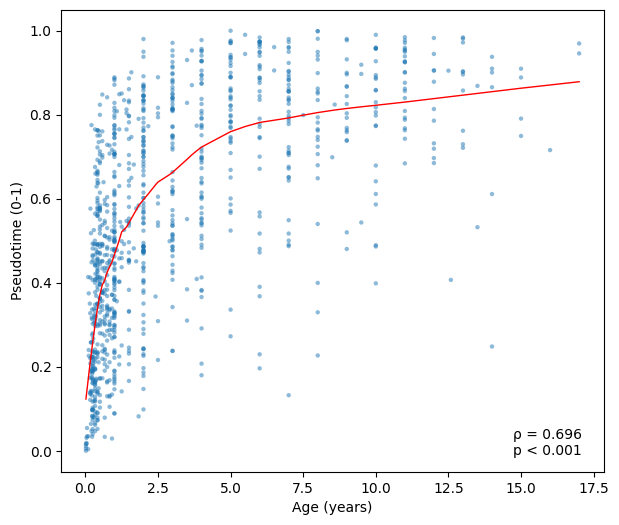

In [43]:
# Graph

fig, ax = plt.subplots(figsize=(7,6))

# Plot
ax.scatter(main_cluster_age, pseudotime_rescale,
           alpha = 0.5, # Transparency
           edgecolors= "none", # No outline
           s = 10, # Marker area
           )

# Line
ax.plot( # Draw the line
    loess_trend[:, 0], # LOESS X values
    loess_trend[:, 1], # LOESS Y Values (psuedotime)
    linewidth = 1,
    color = "red"
)
ax.set_ylabel("Pseudotime (0-1)")
ax.set_xlabel("Age (years)")
# ax.set_title("Pseudotime vs Age")

# Spearman p
ax.text(0.96, 0.03, f"ρ = {spearman_r:.3f}\np < 0.001", # Basic, how far across and up, text (string of ρ = variable quantity, newline and p val)
         transform = ax.transAxes, # Make the across and how far values fractions of the plot/coordinates
         va = "bottom",
         ha = "right" # Add the text to be anchored on the bottom right
         ) 


# Save
fig.savefig("pseudotime_vs_age.pdf", bbox_inches="tight")

What distinguishes the upper right and main cluster? Compare the composition between the two clusters

In [40]:
# Read in the just header of merged_metaphlan for sample names

sample_name_full_header = pd.read_csv("qc0_full_sample_name_abundance.csv", nrows=0)
print("Sanity check = shape;", sample_name_full_header.shape)
# Clade name + sample ids = 1149

# Col namese > Sample list
sample_names_raw = pd.Series(sample_name_full_header.columns[1:]) # The names are the columns after the first one, and turn it to the series
# Sanity check, length = number of names
print("len, sample names raw:", len(sample_names_raw))




Sanity check = shape; (0, 1149)
len, sample names raw: 1148


In [ ]:
# Bray curtis umap -> more common in microbiome studies, abundances matter more than pattern of abundances
reducer_bray_curtis = umap.UMAP(
    metric='braycurtis',
    n_neighbors=12,
    min_dist=0.25,
    random_state=42
)
embed_bray_curtis = reducer_bray_curtis.fit_transform(renorm_order_features_df)

# Check the shape of the UMAP embedding
print("UMAP embedding shape:", embed_bray_curtis.shape)
# Check if the index of metadata and log_order_abundance are equal
print(metadata.index.equals(renorm_order_features_df.index))

/Users/madeline/Desktop/lab2/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (1125, 2)
True


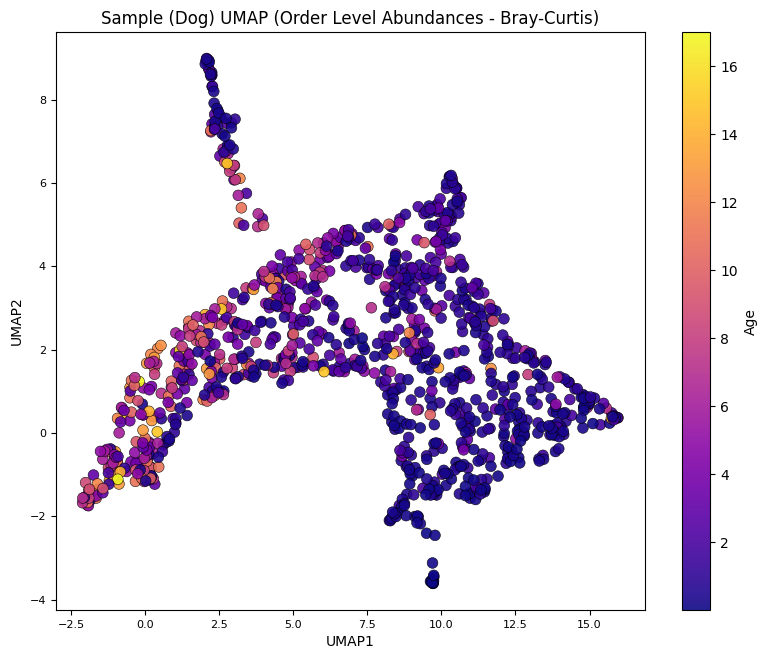

In [ ]:
# Create UMAP and plot

plt.figure(figsize=(9.5,7.5))

plot_bray_curtis = plt.scatter(
    embed_bray_curtis[:,0],
    embed_bray_curtis[:,1],
    c=metadata["age"],
    cmap="plasma",
    s=60,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.4
)

plt.xlabel("UMAP1", fontsize=10)
plt.ylabel("UMAP2", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title("Sample (Dog) UMAP (Order Level Abundances - Bray-Curtis)", fontsize=12)

cbar = plt.colorbar(plot_bray_curtis)
cbar.set_label("Age", fontsize=10)
plt.show()